# データサイエンス特論 第15回 演習課題
青山学院大学大学院 理工学研究科 理工学専攻 知能情報コース 修士1年 35626302 森下剛

In [233]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

## 総合演習

#### 演習問題1の解答

In [234]:
# Mushroom データセットの読み込み
mushroom_df = pd.read_csv('data/mushroom.csv')

print(mushroom_df.shape)
mushroom_df.head()

(8124, 23)


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


#### 演習問題2の解答

In [235]:
# 各属性の欠損値の有無を確認
print(mushroom_df.isnull().sum())
print('欠損値の合計:', mushroom_df.isnull().sum().sum())

cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
poisonous                      0
dtype: int64
欠損値の合計: 2480


In [236]:
# 各列の値の分布を数値で確認
for col in mushroom_df.columns:
    print(f'--- {col} ---')
    print(mushroom_df[col].value_counts())
    print()

--- cap-shape ---
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64

--- cap-surface ---
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64

--- cap-color ---
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64

--- bruises ---
bruises
f    4748
t    3376
Name: count, dtype: int64

--- odor ---
odor
n    3528
f    2160
y     576
s     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64

--- gill-attachment ---
gill-attachment
f    7914
a     210
Name: count, dtype: int64

--- gill-spacing ---
gill-spacing
c    6812
w    1312
Name: count, dtype: int64

--- gill-size ---
gill-size
b    5612
n    2512
Name: count, dtype: int64

--- gill-color ---
gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     408
e      96
y      86
o      64
r      24
Name: count, dtype: int64

--- s

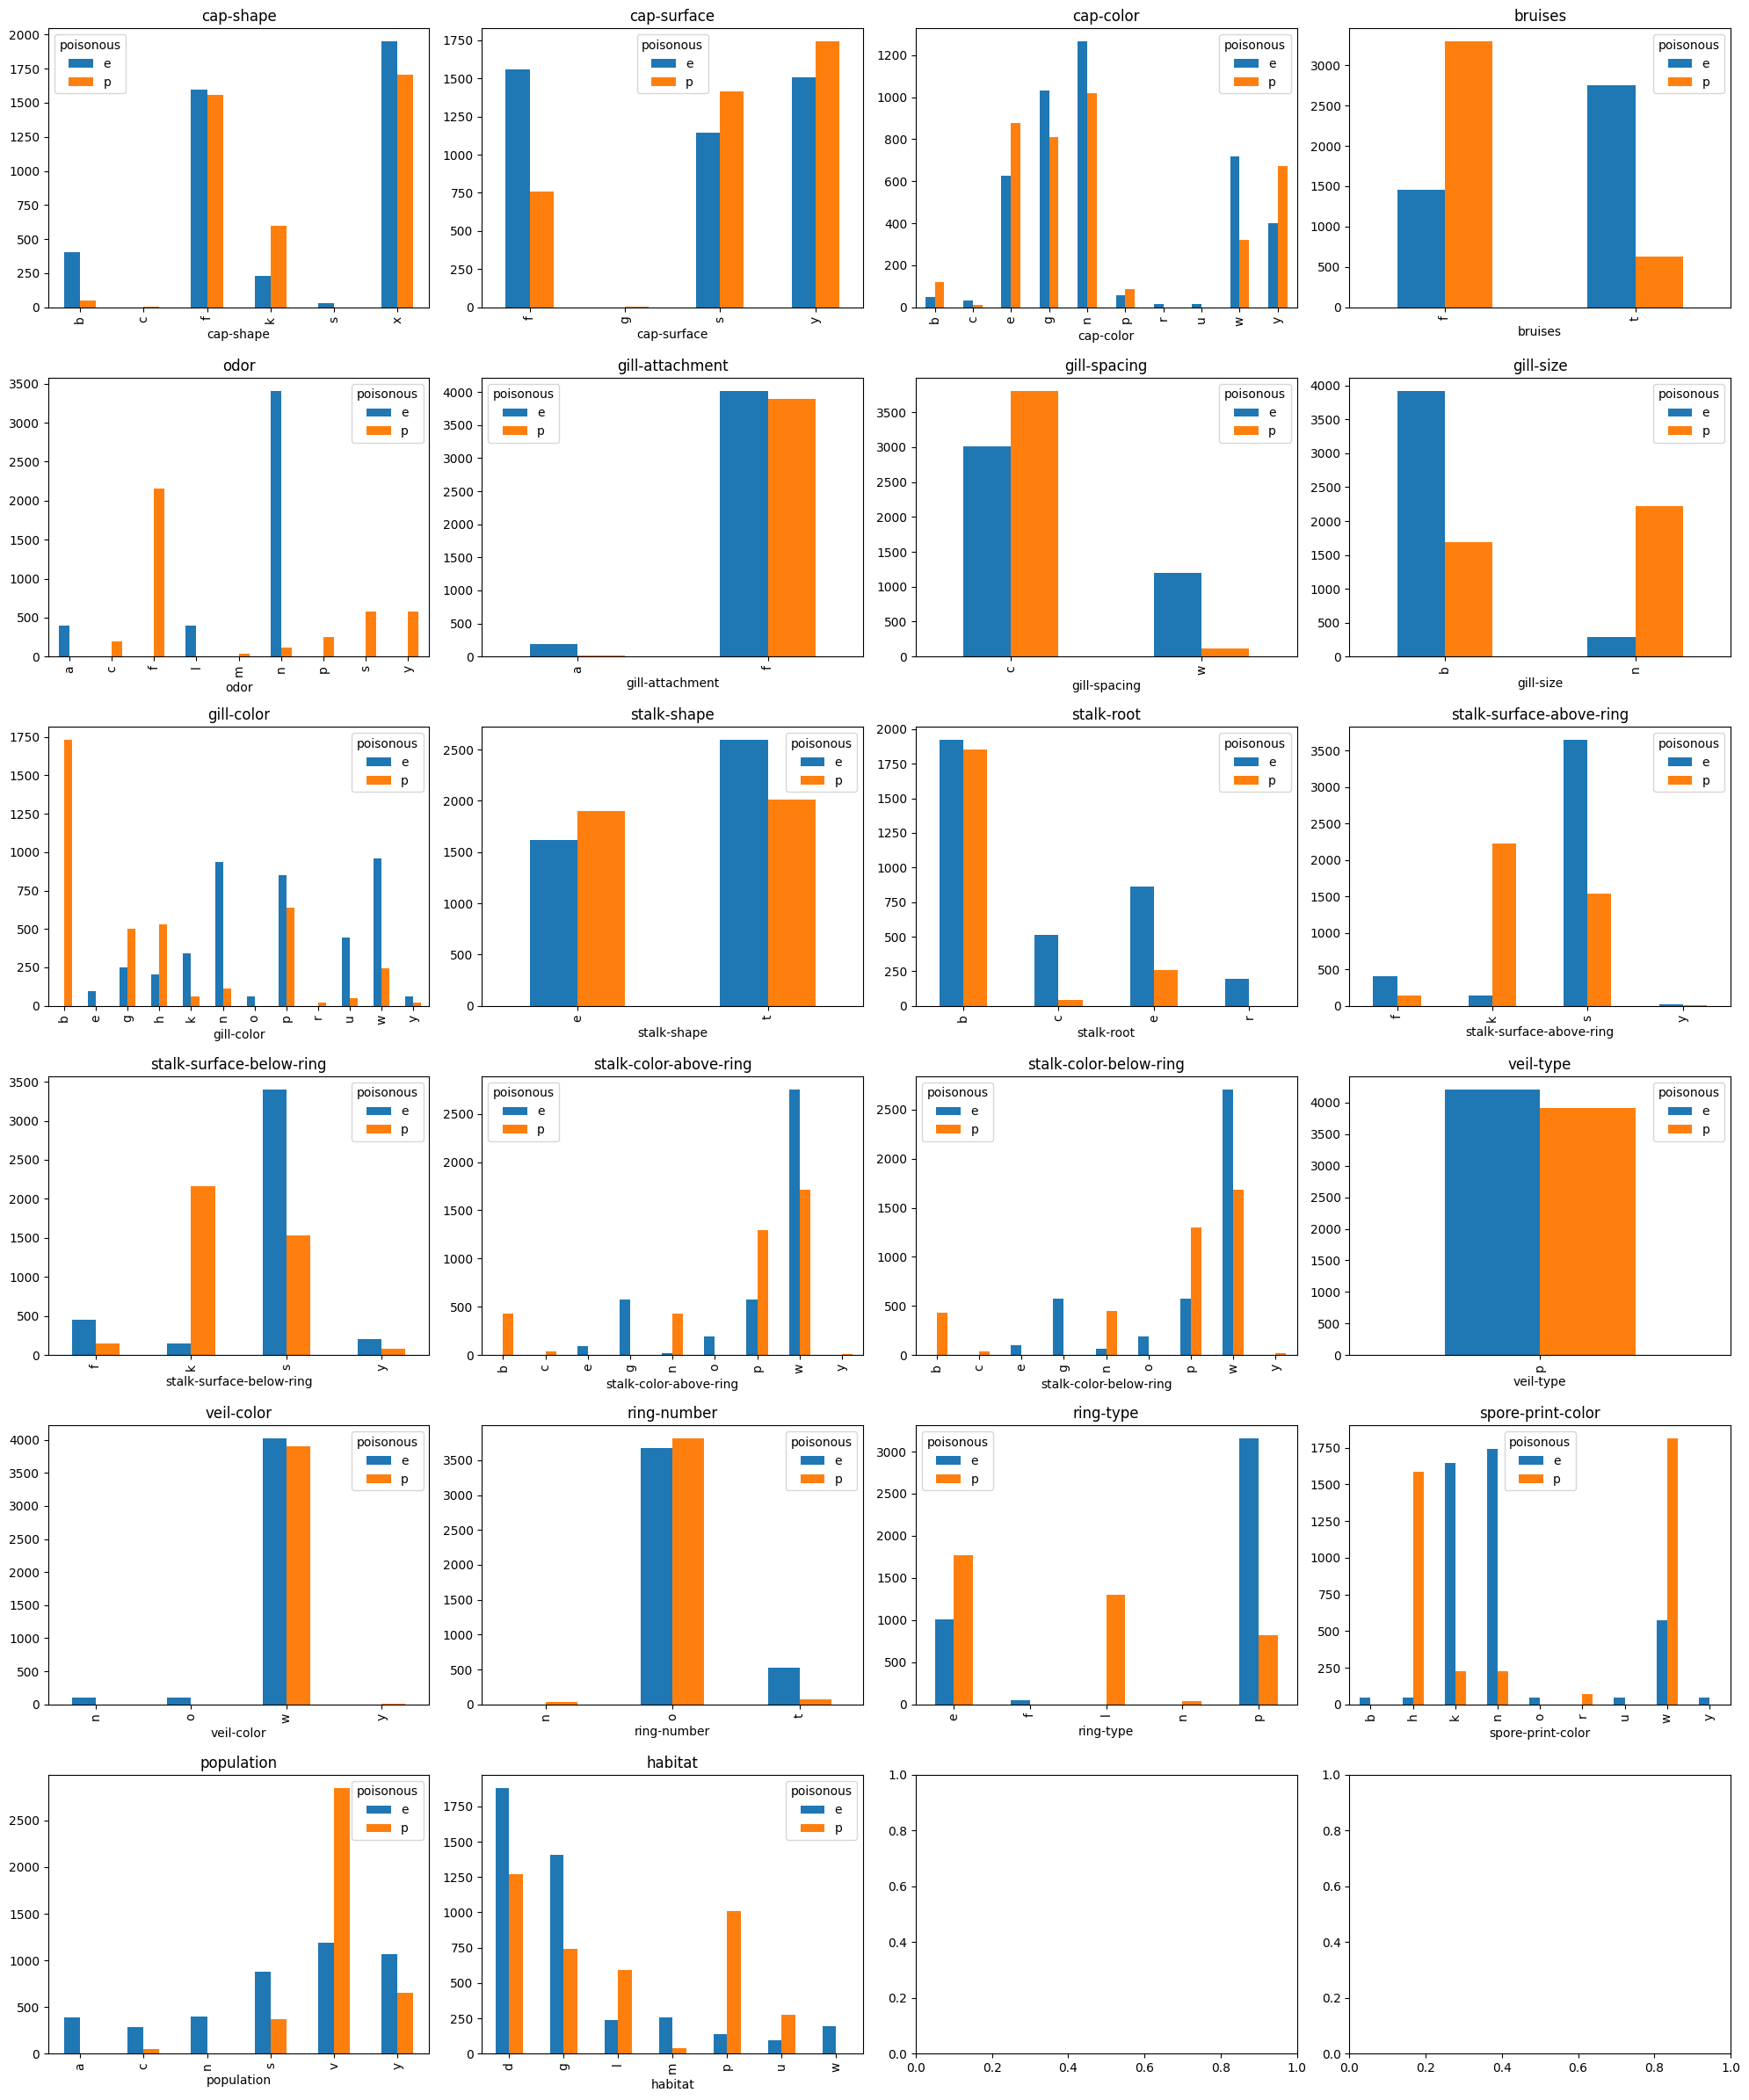

In [237]:
# 目的変数の値ごとに各説明変数の分布を可視化
feature_df = mushroom_df.drop(columns='poisonous')
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
axes = axes.flatten()
for ax, (col, s) in zip(axes, feature_df.items()):
    ct = pd.crosstab(s, mushroom_df['poisonous'])
    ct.plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.legend(title='poisonous')
plt.tight_layout()
plt.show()

#### 演習問題3の解答

In [238]:
# クラスの分布が崩れないよう stratify を指定する
mushroom_train_df, mushroom_test_df = train_test_split(
    mushroom_df,
    test_size=0.2,
    random_state=1,
    stratify=mushroom_df['poisonous'],
)

print('train:', mushroom_train_df.shape, 'test:', mushroom_test_df.shape)
print('全体のクラス分布')
print(mushroom_df['poisonous'].value_counts(normalize=True))
print('訓練データのクラス分布')
print(mushroom_train_df['poisonous'].value_counts(normalize=True))
print('テストデータのクラス分布')
print(mushroom_test_df['poisonous'].value_counts(normalize=True))

train: (6499, 23) test: (1625, 23)
全体のクラス分布
poisonous
e    0.517971
p    0.482029
Name: proportion, dtype: float64
訓練データのクラス分布
poisonous
e    0.517926
p    0.482074
Name: proportion, dtype: float64
テストデータのクラス分布
poisonous
e    0.518154
p    0.481846
Name: proportion, dtype: float64


#### 演習問題4の解答

In [239]:
# すべて名義属性のため one-hot エンコーディングで数値化する
train_df = pd.get_dummies(mushroom_train_df)

print(train_df.shape)
train_df.head()

(6499, 118)


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,poisonous_e,poisonous_p
5476,False,False,False,False,False,True,False,False,False,True,...,False,False,True,False,False,False,False,False,False,True
4410,False,False,True,False,False,False,True,False,False,False,...,True,True,False,False,False,False,False,False,True,False
223,False,False,True,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
2068,False,False,True,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False
3142,False,False,True,False,False,False,False,False,False,True,...,True,True,False,False,False,False,False,False,True,False


#### 演習問題5の解答

In [240]:
X_train = train_df.drop(columns=['poisonous_e', 'poisonous_p'])
y_train = train_df['poisonous_p']

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print(y_train.value_counts())

X_train: (6499, 116)
y_train: (6499,)
poisonous_p
False    3366
True     3133
Name: count, dtype: int64


#### 演習問題6の解答

In [241]:
# テストデータも同様に one-hot エンコーディングし、列を X_train に揃える
test_df = pd.get_dummies(mushroom_test_df)
X_test = test_df.drop(columns=['poisonous_e', 'poisonous_p']).reindex(
    columns=X_train.columns, fill_value=0
)
y_test = test_df['poisonous_p']

print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_test: (1625, 116)
y_test: (1625,)


In [242]:
# ロジスティック回帰モデルを学習し、テストデータに対する精度を求める
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print('LogisticRegression accuracy =', accuracy_score(y_test, y_pred_lr))

LogisticRegression accuracy = 1.0


In [243]:
# k近傍法モデルを学習し、テストデータに対する精度を求める
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print('KNeighborsClassifier accuracy =', accuracy_score(y_test, y_pred_knn))

KNeighborsClassifier accuracy = 1.0


#### 演習問題7の解答

In [244]:
mushroom_train_df100, mushroom_test_df100 = train_test_split(
    mushroom_df,
    test_size=0.2,
    random_state=100,
    stratify=mushroom_df['poisonous'],
)

train_df100 = pd.get_dummies(mushroom_train_df100)
test_df100 = pd.get_dummies(mushroom_test_df100)

X_train100 = train_df100.drop(columns=['poisonous_e', 'poisonous_p'])
y_train100 = train_df100['poisonous_p']
X_test100 = test_df100.drop(columns=['poisonous_e', 'poisonous_p'])
y_test100 = test_df100['poisonous_p']

In [245]:
lr100 = LogisticRegression()
lr100.fit(X_train100, y_train100)
lr100.predict(X_test100)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- cap-surface_g


In [246]:
# cap-surface_g の分析
print('訓練データの cap-surface')
print(mushroom_train_df100['cap-surface'].value_counts())
print('テストデータの cap-surface')
print(mushroom_test_df100['cap-surface'].value_counts())

print('X_train100 の列数:', X_train100.shape[1])
print('X_test100 の列数 :', X_test100.shape[1])

訓練データの cap-surface
cap-surface
y    2585
s    2048
f    1862
g       4
Name: count, dtype: int64
テストデータの cap-surface
cap-surface
y    659
s    508
f    458
Name: count, dtype: int64
X_train100 の列数: 116
X_test100 の列数 : 115


**エラー内容の分析**

random_state を100にすると分割形式が変わり、出現数の少ないカテゴリ値がすべて訓練データ側に入り、テストデータには現れなくなる。
そのため訓練データとテストデータに別々に pd.get_dummies を適用すると、テストデータ側では cap-surface_g 列が作られず、one-hot 後の列が 116列と115列のように一致しなくなる。

**回避方法**

テストデータの列を reindex(columns=X_train100.columns, fill_value=0) で訓練データの列に揃えることで列数を一致させる。

In [247]:
# reindex でテストデータの列を訓練データに揃えて回避する
X_test100 = X_test100.reindex(columns=X_train100.columns, fill_value=0)
print(X_test100.shape[1])

# ロジスティック回帰
lr100 = LogisticRegression()
lr100.fit(X_train100, y_train100)
print('LogisticRegression accuracy =', accuracy_score(y_test100, lr100.predict(X_test100)))

# k近傍法
knn100 = KNeighborsClassifier()
knn100.fit(X_train100, y_train100)
print('KNeighborsClassifier accuracy =', accuracy_score(y_test100, knn100.predict(X_test100)))

116
LogisticRegression accuracy = 1.0
KNeighborsClassifier accuracy = 1.0
